In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import statsmodels.api as sm

In [ ]:
df = pd.read_excel("Dataset_after_cleaning.xlsx")

In [3]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region7,Region8,Region9,ReturningVisitor,NewVisitor,OtherVisitor,IfWeekend,Y_IfRevenue,OperatingSystemOther,BrowserOther
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,0,0,0,1,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,...,0,0,0,1,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,0,0,1,1,0,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,...,0,0,0,1,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,...,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,...,0,0,0,1,0,0,1,0,1,1
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,...,0,0,0,1,0,0,1,0,0,0
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,...,0,0,0,1,0,0,1,0,0,0
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,...,0,0,0,1,0,0,0,0,0,0


# Pierwszy model

In [4]:
df_logit = df.drop(columns=['ReturningVisitor', 'OtherVisitor', 'BounceRates', 'Region1', 'Month_5', 'OperatingSystem2', 'Browser2', 'PageValues'])

Dokładność modelu: 0.6448

Macierz pomyłek:
[[1366  823]
 [  97  304]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.93      0.62      0.75      2189
           1       0.27      0.76      0.40       401

    accuracy                           0.64      2590
   macro avg       0.60      0.69      0.57      2590
weighted avg       0.83      0.64      0.69      2590



Dokładność modelu: 0.6448

Macierz pomyłek:
[[1366  823]
 [  97  304]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.93      0.62      0.75      2189
           1       0.27      0.76      0.40       401

    accuracy                           0.64      2590
   macro avg       0.60      0.69      0.57      2590
weighted avg       0.83      0.64      0.69      2590



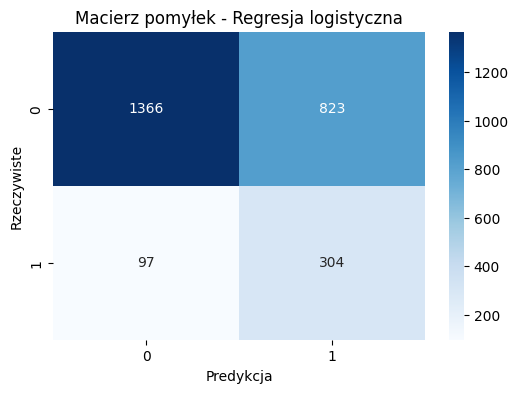

In [5]:
X = df_logit.drop('Y_IfRevenue', axis=1)
Y = df_logit['Y_IfRevenue']

#podział na zbiór testowy i walidacyjny
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.30, random_state=42, stratify=Y_train_val)

#skalowanie zmiennych - tylko zmienne niebinarne
kolumny_do_skalowania = []
kolumny_binarne = []

for column in X.columns:
    if len(X[column].unique()) > 2:
        kolumny_do_skalowania.append(column)
    else:
        kolumny_binarne.append(column)
       
X_train_binarne = X_train[kolumny_binarne]
X_val_binarne = X_val[kolumny_binarne]
X_test_binarne = X_test[kolumny_binarne]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train[kolumny_do_skalowania])
X_val_sc = scaler.transform(X_val[kolumny_do_skalowania])
X_test_sc = scaler.transform(X_test[kolumny_do_skalowania])

# zamiana array -> DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_sc,
    columns=kolumny_do_skalowania,
    index=X_train.index)
X_val_scaled_df = pd.DataFrame(
    X_val_sc,
    columns=kolumny_do_skalowania,
    index=X_val.index)
X_test_scaled_df = pd.DataFrame(
    X_test_sc,
    columns=kolumny_do_skalowania,
    index=X_test.index)

#Sklejenie binarnych i skalowanych zmiennych
X_train_scaled = pd.concat([X_train_scaled_df, X_train_binarne], axis=1)
X_val_scaled = pd.concat([X_val_scaled_df, X_val_binarne], axis=1)
X_test_scaled = pd.concat([X_test_scaled_df, X_test_binarne], axis=1)
#uporządkowanie kolumn
X_train_scaled = X_train_scaled[X.columns]
X_val_scaled = X_val_scaled[X.columns]
X_test_scaled = X_test_scaled[X.columns]

#trenowanie modelu
modelLogit = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelLogit.fit(X_train_scaled, Y_train)

#predykcje
Y_pred = modelLogit.predict(X_val_scaled)

#ocena
acc = accuracy_score(Y_val, Y_pred)
print(f"Dokładność modelu: {acc:.4f}")
print("\nMacierz pomyłek:")
print(confusion_matrix(Y_val, Y_pred))
print("\nRaport klasyfikacji:")
print(classification_report(Y_val, Y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Regresja logistyczna")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

In [6]:
class_weights = compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)
class_weights_dict = dict(zip(np.unique(Y_train), class_weights))

print("Wagi przypisane do klas (balanced):")
for cls, w in class_weights_dict.items():
    print(f"Klasa {cls}: {w:.3f}")

Wagi przypisane do klas (balanced):
Klasa 0: 0.592
Klasa 1: 3.230


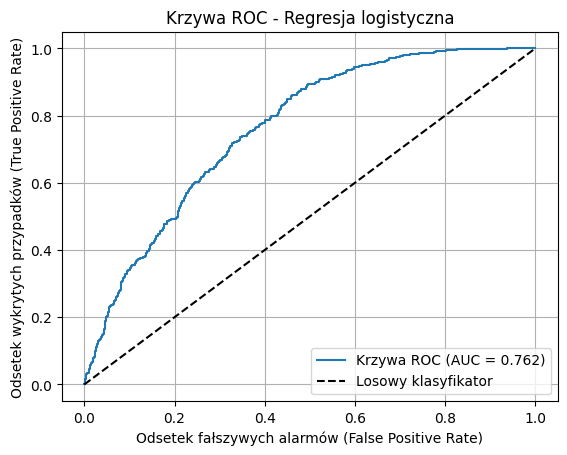

In [7]:
#krzywa roc
Y_pred_proba = modelLogit.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_val, Y_pred_proba)
roc_auc = roc_auc_score(Y_val, Y_pred_proba)

plt.plot(fpr, tpr, label = f'Krzywa ROC (AUC = {roc_auc:.3f})') #f-string zmienna: .3 -> format zmiennej 3 miejsca po przecinku
plt.plot([0,1], [0,1], 'k--', label = 'Losowy klasyfikator')
plt.xlabel('Odsetek fałszywych alarmów (False Positive Rate)')
plt.ylabel('Odsetek wykrytych przypadków (True Positive Rate)')
plt.title('Krzywa ROC - Regresja logistyczna')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


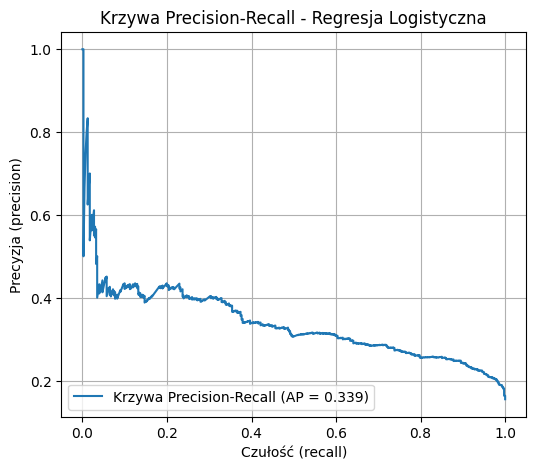

In [8]:
#Krzywa precision-recall
Y_pred_proba = modelLogit.predict_proba(X_val_scaled)[:,1]
precision, recall, thresholds = precision_recall_curve(Y_val, Y_pred_proba)
avg_precision = average_precision_score(Y_val, Y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label = f'Krzywa Precision-Recall (AP = {avg_precision:.3f})')
plt.xlabel('Czułość (recall)')
plt.ylabel('Precyzja (precision)')
plt.title('Krzywa Precision-Recall - Regresja Logistyczna')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Obcinam outliery (clip) i tworzę nowy model

In [9]:
kol_do_winsoryzacji = []
for col in df_logit.columns:
    if col != 'SpecialDay' and len(df_logit[col].unique()) > 2:
        kol_do_winsoryzacji.append(col)
        print("dodano kolumnę", col)

dodano kolumnę Administrative
dodano kolumnę Administrative_Duration
dodano kolumnę Informational
dodano kolumnę Informational_Duration
dodano kolumnę ProductRelated
dodano kolumnę ProductRelated_Duration
dodano kolumnę ExitRates


In [10]:
for col in kol_do_winsoryzacji:
    Q = X_train[col].quantile(0.9)
    df_logit[col] = df_logit[col].clip(0, Q) # obcinam wartości odstające na podstawie kwantyla 0,9 obliczonego na x-train


In [11]:
df_logit['Administrative']

0        0
1        0
2        0
3        0
4        0
        ..
12325    3
12326    0
12327    0
12328    4
12329    0
Name: Administrative, Length: 12330, dtype: int64

Dokładność modelu: 0.6552

Macierz pomyłek:
[[1391  798]
 [  95  306]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76      2189
           1       0.28      0.76      0.41       401

    accuracy                           0.66      2590
   macro avg       0.61      0.70      0.58      2590
weighted avg       0.83      0.66      0.70      2590



Dokładność modelu: 0.6552

Macierz pomyłek:
[[1391  798]
 [  95  306]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76      2189
           1       0.28      0.76      0.41       401

    accuracy                           0.66      2590
   macro avg       0.61      0.70      0.58      2590
weighted avg       0.83      0.66      0.70      2590



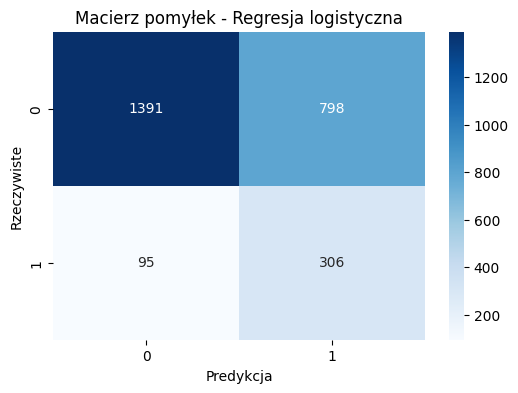

In [12]:
X = df_logit.drop('Y_IfRevenue', axis=1)
Y = df_logit['Y_IfRevenue']

#podział na zbiór testowy i walidacyjny
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.30, random_state=42, stratify=Y_train_val)

#skalowanie zmiennych - tylko zmienne niebinarne
kolumny_do_skalowania = []
kolumny_binarne = []

for column in X.columns:
    if len(X[column].unique()) > 2:
        kolumny_do_skalowania.append(column)
    else:
        kolumny_binarne.append(column)

X_train_binarne = X_train[kolumny_binarne]
X_val_binarne = X_val[kolumny_binarne]
X_test_binarne = X_test[kolumny_binarne]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train[kolumny_do_skalowania])
X_val_sc = scaler.transform(X_val[kolumny_do_skalowania])
X_test_sc = scaler.transform(X_test[kolumny_do_skalowania])

# zamiana array -> DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_sc,
    columns=kolumny_do_skalowania,
    index=X_train.index)
X_val_scaled_df = pd.DataFrame(
    X_val_sc,
    columns=kolumny_do_skalowania,
    index=X_val.index)
X_test_scaled_df = pd.DataFrame(
    X_test_sc,
    columns=kolumny_do_skalowania,
    index=X_test.index)

#Sklejenie binarnych i skalowanych zmiennych
X_train_scaled = pd.concat([X_train_scaled_df, X_train_binarne], axis=1)
X_val_scaled = pd.concat([X_val_scaled_df, X_val_binarne], axis=1)
X_test_scaled = pd.concat([X_test_scaled_df, X_test_binarne], axis=1)
#uporządkowanie kolumn
X_train_scaled = X_train_scaled[X.columns]
X_val_scaled = X_val_scaled[X.columns]
X_test_scaled = X_test_scaled[X.columns]

#trenowanie modelu
modelLogit = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelLogit.fit(X_train_scaled, Y_train)

#predykcje
Y_pred = modelLogit.predict(X_val_scaled)

#ocena
acc = accuracy_score(Y_val, Y_pred)
print(f"Dokładność modelu: {acc:.4f}")
print("\nMacierz pomyłek:")
print(confusion_matrix(Y_val, Y_pred))
print("\nRaport klasyfikacji:")
print(classification_report(Y_val, Y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Regresja logistyczna")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

In [13]:
X_train_scaled

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,SpecialDay,Month_2,Month_3,...,Region4,Region5,Region6,Region7,Region8,Region9,NewVisitor,IfWeekend,OperatingSystemOther,BrowserOther
910,0.806684,2.167798,-0.489792,-0.430933,-1.084899,-1.018909,0.479754,-0.313805,0,1,...,0,0,0,0,1,0,1,0,0,0
10610,-0.406455,-0.661513,-0.489792,-0.430933,0.157138,2.054351,-1.021617,-0.313805,0,0,...,0,0,0,0,1,0,0,0,0,0
6828,-0.406455,-0.446191,0.958487,2.677830,-0.818748,-0.685133,-1.213067,-0.313805,0,0,...,0,0,0,0,0,0,0,0,0,0
827,-0.810834,-0.727971,-0.489792,-0.430933,-0.552598,-0.885558,-0.507725,-0.313805,0,1,...,0,0,0,0,0,0,0,0,0,0
9033,-0.810834,-0.727971,-0.489792,-0.430933,-0.552598,-0.742359,-0.692199,-0.313805,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,0.806684,0.082809,-0.489792,-0.430933,-0.419522,-0.474120,-0.890625,-0.313805,0,0,...,0,0,0,0,0,0,0,1,1,0
9915,2.019823,2.167798,-0.489792,-0.430933,1.177383,0.733685,-1.088275,-0.313805,0,0,...,0,0,0,0,0,0,0,0,0,0
3800,-0.002075,2.167798,-0.489792,-0.430933,-0.863107,-0.423706,-0.729404,-0.313805,0,0,...,0,0,0,0,0,0,1,0,0,0
10436,-0.002075,-0.581764,-0.489792,-0.430933,-0.641314,0.039229,0.299930,-0.313805,0,0,...,0,0,0,0,0,0,0,0,0,0


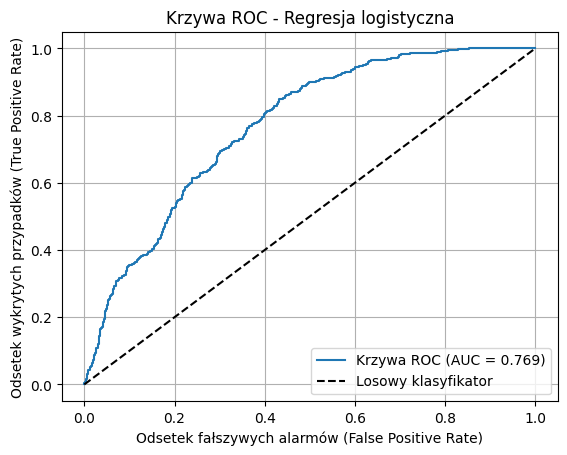

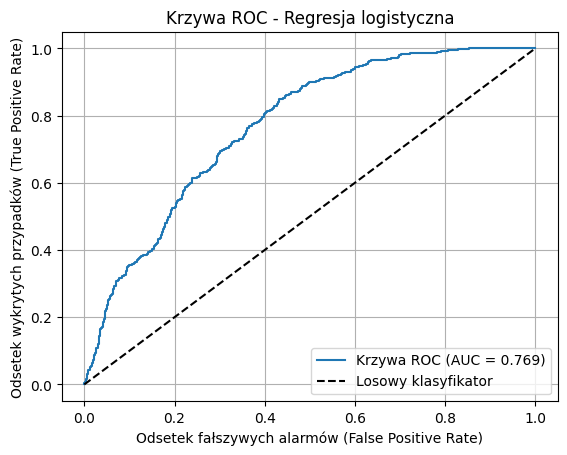

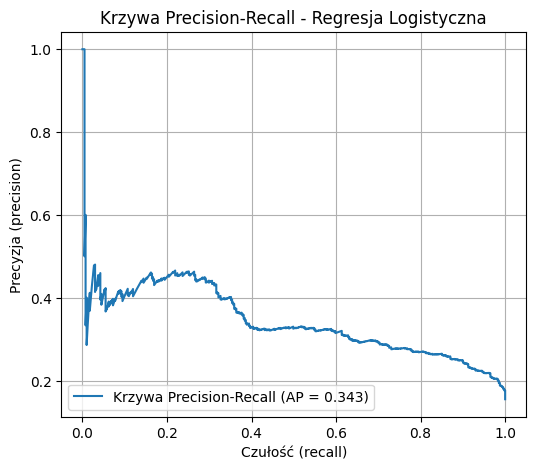

In [14]:
#krzywa roc
Y_pred_proba = modelLogit.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_val, Y_pred_proba)
roc_auc = roc_auc_score(Y_val, Y_pred_proba)

plt.plot(fpr, tpr, label = f'Krzywa ROC (AUC = {roc_auc:.3f})') #f-string zmienna: .3 -> format zmiennej 3 miejsca po przecinku
plt.plot([0,1], [0,1], 'k--', label = 'Losowy klasyfikator')
plt.xlabel('Odsetek fałszywych alarmów (False Positive Rate)')
plt.ylabel('Odsetek wykrytych przypadków (True Positive Rate)')
plt.title('Krzywa ROC - Regresja logistyczna')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Krzywa precision-recall
Y_pred_proba = modelLogit.predict_proba(X_val_scaled)[:,1]
precision, recall, thresholds = precision_recall_curve(Y_val, Y_pred_proba)
avg_precision = average_precision_score(Y_val, Y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label = f'Krzywa Precision-Recall (AP = {avg_precision:.3f})')
plt.xlabel('Czułość (recall)')
plt.ylabel('Precyzja (precision)')
plt.title('Krzywa Precision-Recall - Regresja Logistyczna')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Optymalny próg decyzyjny

Optymalny próg decyzyjny: 0.541
Precision przy tym progu: 0.293
Recall przy tym progu: 0.701


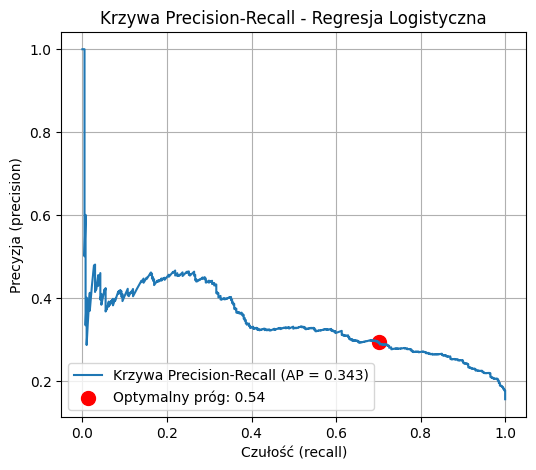

In [15]:
# DLA RECALL = 0,7

# Krzywa precision-recall - optymalny threshold (target recall)
Y_pred_proba = modelLogit.predict_proba(X_val_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(Y_val, Y_pred_proba)
avg_precision = average_precision_score(Y_val, Y_pred_proba)

target_recall = 0.7

# precision i recall mają o 1 element więcej niż thresholds
# dlatego operujemy na precision[:-1] i recall[:-1]
idx = np.where(recall[:-1] >= target_recall)[0]

if len(idx) == 0:
    raise ValueError("Brak progu spełniającego zadany target recall")

# wybieramy próg z najwyższą precision
best_idx = idx[np.argmax(precision[idx])]
best_threshold = thresholds[best_idx]

print(f"Optymalny próg decyzyjny: {best_threshold:.3f}")
print(f"Precision przy tym progu: {precision[best_idx]:.3f}")
print(f"Recall przy tym progu: {recall[best_idx]:.3f}")

Y_pred_opt = (Y_pred_proba >= best_threshold).astype(int)

# Wykres
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Krzywa Precision-Recall (AP = {avg_precision:.3f})')
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color='red',
    s=100,
    label=f'Optymalny próg: {best_threshold:.2f}'
)
plt.xlabel('Czułość (recall)')
plt.ylabel('Precyzja (precision)')
plt.title('Krzywa Precision-Recall - Regresja Logistyczna')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# różnica w precyzji między recall 0,8 a 0,9 jest niewielka (3pp) więc lepiej zwiększyć recall do 0,9, bo przynajmniej więcej osób wykryjemy, a po prostu będziemy bardziej spamować kodami rabatowymi. - opisać to w pracy

Optymalny próg decyzyjny: 0.412
Precision przy tym progu: 0.249
Recall przy tym progu: 0.900


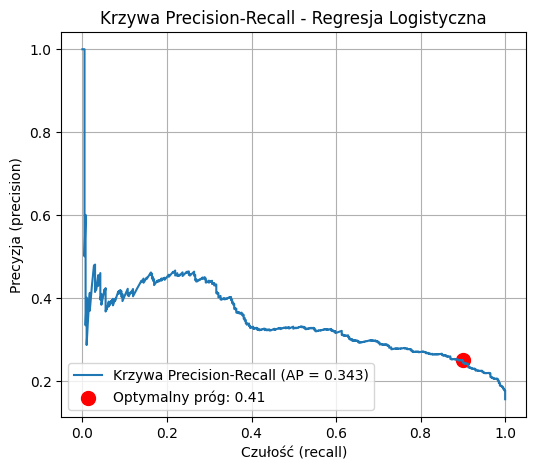

In [16]:
# DLA RECALL = 0,9

# Krzywa precision-recall - optymalny threshold (target recall)
Y_pred_proba = modelLogit.predict_proba(X_val_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(Y_val, Y_pred_proba)
avg_precision = average_precision_score(Y_val, Y_pred_proba)

target_recall = 0.9

# precision i recall mają o 1 element więcej niż thresholds
# dlatego operujemy na precision[:-1] i recall[:-1]
idx = np.where(recall[:-1] >= target_recall)[0]

if len(idx) == 0:
    raise ValueError("Brak progu spełniającego zadany target recall")

# wybieramy próg z najwyższą precision
best_idx = idx[np.argmax(precision[idx])]
best_threshold = thresholds[best_idx]

print(f"Optymalny próg decyzyjny: {best_threshold:.3f}")
print(f"Precision przy tym progu: {precision[best_idx]:.3f}")
print(f"Recall przy tym progu: {recall[best_idx]:.3f}")

Y_pred_opt = (Y_pred_proba >= best_threshold).astype(int)

# Wykres
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Krzywa Precision-Recall (AP = {avg_precision:.3f})')
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color='red',
    s=100,
    label=f'Optymalny próg: {best_threshold:.2f}'
)
plt.xlabel('Czułość (recall)')
plt.ylabel('Precyzja (precision)')
plt.title('Krzywa Precision-Recall - Regresja Logistyczna')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Macierz pomyłek po zmianie progu i obcięciu wartości odstających

Dokładność modelu: 0.5633

Macierz pomyłek:
[[1098 1091]
 [  40  361]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.96      0.50      0.66      2189
           1       0.25      0.90      0.39       401

    accuracy                           0.56      2590
   macro avg       0.61      0.70      0.52      2590
weighted avg       0.85      0.56      0.62      2590



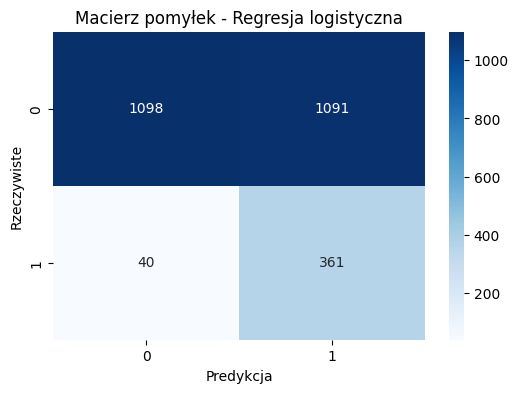

In [17]:
#ocena
acc = accuracy_score(Y_val, Y_pred_opt)
print(f"Dokładność modelu: {acc:.4f}")
print("\nMacierz pomyłek:")
print(confusion_matrix(Y_val, Y_pred_opt))
print("\nRaport klasyfikacji:")
print(classification_report(Y_val, Y_pred_opt))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_pred_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Regresja logistyczna")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

# Ostateczna ocena na podst danych testowych

Dokładność modelu: 0.5399

Macierz pomyłek:
[[1513 1614]
 [  88  484]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.95      0.48      0.64      3127
           1       0.23      0.85      0.36       572

    accuracy                           0.54      3699
   macro avg       0.59      0.67      0.50      3699
weighted avg       0.83      0.54      0.60      3699



Dokładność modelu: 0.5399

Macierz pomyłek:
[[1513 1614]
 [  88  484]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.95      0.48      0.64      3127
           1       0.23      0.85      0.36       572

    accuracy                           0.54      3699
   macro avg       0.59      0.67      0.50      3699
weighted avg       0.83      0.54      0.60      3699



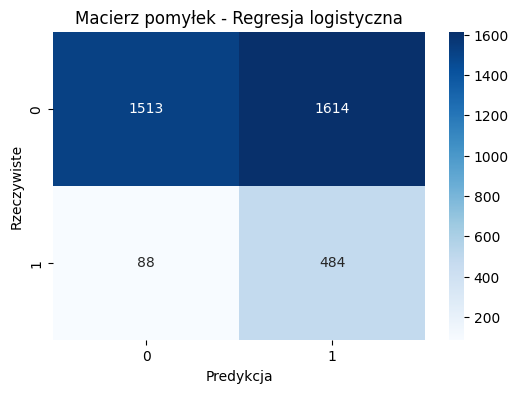

In [18]:
#predykcje
Y_pred_opt = modelLogit.predict(X_test_scaled)

#ocena
acc = accuracy_score(Y_test, Y_pred_opt)
print(f"Dokładność modelu: {acc:.4f}")
print("\nMacierz pomyłek:")
print(confusion_matrix(Y_test, Y_pred_opt))
print("\nRaport klasyfikacji:")
print(classification_report(Y_test, Y_pred_opt))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, Y_pred_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Regresja logistyczna")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

In [19]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [20]:
#współczynniki beta i logarytmy szans - kierunek i siła wpływu zmiennych na y
coef_df = pd.DataFrame({
    'cecha': X_train_scaled_df.columns,
    'beta': modelLogit.coef_[0]
}).sort_values(by='beta', ascending=False)

coef_df['odds_ratio'] = np.exp(coef_df['beta'])
coef_df


,cecha,beta,odds_ratio
15,Month_11,0.738712,2.093238
14,Month_10,0.651506,1.918427
13,Month_9,0.556830,1.745132
28,NewVisitor,0.325244,1.384369
5,ProductRelated_Duration,0.295695,1.344061
12,Month_8,0.295402,1.343667
19,Browser1,0.282846,1.326901
11,Month_7,0.239537,1.270660
31,BrowserOther,0.181265,1.198733
2,Informational,0.132445,1.141617


In [21]:
#wyraz wolny - prawdopodobieństwo bazowe
modelLogit.intercept_
base_prob = 1 / (1 + np.exp(-modelLogit.intercept_[0]))
base_prob

0.3536701546389453

In [22]:
Y_pred_proba_test = modelLogit.predict_proba(X_test_scaled)[:, 1]
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(
    Y_test,
    Y_pred_proba_test,
    n_bins=10,
    strategy='uniform'
)

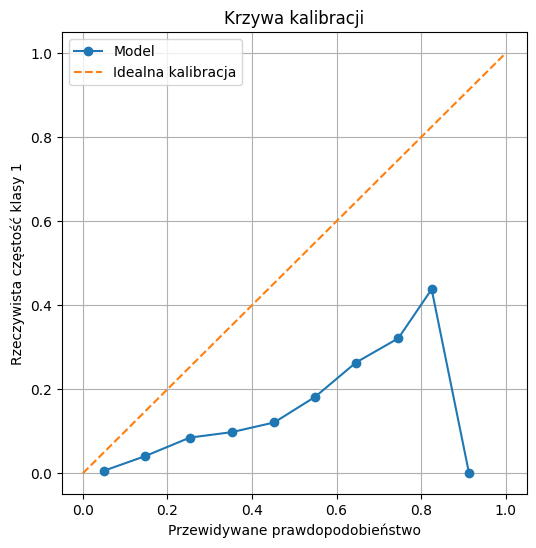

In [23]:
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker = 'o', label = 'Model')
plt.plot([0,1], [0, 1], linestyle='--', label='Idealna kalibracja')
plt.xlabel('Przewidywane prawdopodobieństwo')
plt.ylabel('Rzeczywista częstość klasy 1')
plt.title('Krzywa kalibracji')
plt.legend()
plt.grid()
plt.show()
#poniżej przekątnej - model przeszacowuje (mówi 60%, a jest np. 40%)

In [24]:
#wyniki statystyczne
import statsmodels.api as sm

X_train_scaled_df.index = Y_train.index
X_sm = sm.add_constant(X_train_scaled_df)
model_sm = sm.Logit(Y_train, X_sm)
result = model_sm.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.372793
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            Y_IfRevenue   No. Observations:                 6041
Model:                          Logit   Df Residuals:                     6008
Method:                           MLE   Df Model:                           32
Date:                Sat, 10 Jan 2026   Pseudo R-squ.:                  0.1349
Time:                        11:38:56   Log-Likelihood:                -2252.0
converged:                       True   LL-Null:                       -2603.1
Covariance Type:            nonrobust   LLR p-value:                4.210e-127
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.2694      0.116    -19.620      0.000      -2.496   

In [25]:
#tworzę tabelę
coef_df = pd.DataFrame({
    'Beta': result.params.values,
    'p_value': result.pvalues
})

# Liczymy iloraz szans
coef_df['OR'] = np.exp(coef_df['Beta'])

# Sortujemy po wartości bezwzględnej beta (opcjonalnie, żeby najważniejsze cechy były na górze)
coef_df['abs_beta'] = coef_df['Beta'].abs()
coef_df = coef_df.sort_values(by='abs_beta', ascending=False).drop(columns='abs_beta')

# Wyświetlamy tabelę
print(coef_df)

                             Beta       p_value        OR
const                   -2.269437  1.050365e-85  0.103370
Month_2                 -2.041132  4.449223e-02  0.129882
ExitRates               -0.943550  3.449852e-35  0.389244
Month_11                 0.751714  6.216248e-11  2.120632
Month_10                 0.527158  3.577823e-03  1.694111
OperatingSystem3        -0.417684  1.827362e-04  0.658570
Month_9                  0.409582  3.790336e-02  1.506189
OperatingSystem1        -0.387661  3.293707e-02  0.678642
Browser1                 0.310110  9.305326e-02  1.363575
NewVisitor               0.305179  3.819340e-03  1.356868
ProductRelated_Duration  0.288197  1.417644e-05  1.334021
Month_8                  0.230027  2.737877e-01  1.258634
Month_3                 -0.208907  1.434101e-01  0.811470
Month_7                  0.208180  3.712474e-01  1.231435
Region7                 -0.192265  2.520824e-01  0.825089
SpecialDay              -0.191312  3.953374e-03  0.825875
OperatingSyste

In [27]:
Sprawdzenie = X_train_scaled.copy()
Sprawdzenie['Y_IfRevenue'] = Y_train

In [28]:
Sprawdzenie[['Y_IfRevenue', 'SpecialDay']]

,Y_IfRevenue,SpecialDay
910,0,-0.313805
10610,0,-0.313805
6828,0,-0.313805
827,0,-0.313805
9033,0,-0.313805
...,...,...
2755,1,-0.313805
9915,0,-0.313805
3800,0,-0.313805
10436,0,-0.313805


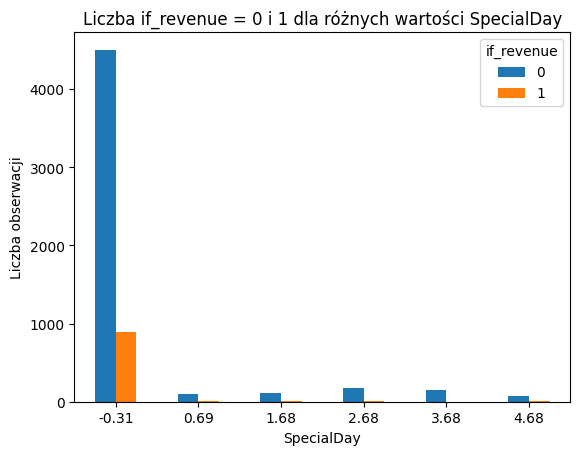

In [29]:
# zliczenie obserwacji
counts = (
    Sprawdzenie
    .groupby(['SpecialDay', 'Y_IfRevenue'])
    .size()
    .unstack(fill_value=0)
)

# wykres
ax = counts.plot(kind='bar')

ax.set_xlabel('SpecialDay')
ax.set_ylabel('Liczba obserwacji')
ax.set_title('Liczba if_revenue = 0 i 1 dla różnych wartości SpecialDay')
ax.legend(title='if_revenue')

# zaokrąglenie etykiet osi X do 2 miejsc
ax.set_xticklabels([f"{x:.2f}" for x in counts.index], rotation=0)

plt.show()